In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('../data/final/생활폐기물_발생및처리_최종_master_단위통일.xlsx')

# 언네임드 제거
df = df.loc[:, ~df.columns.astype(str).str.contains('^Unnamed')]

# 숫자형 정리
for col in df.columns:
    if col not in ['대분류', '자치구']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.shape)
print(df[['자치구', '연도']].head())

(625, 79)
   자치구    연도
0  강남구  2000
1  강남구  2001
2  강남구  2002
3  강남구  2003
4  강남구  2004


# 1. 트랙 A:연도별 서울 장기 추세 현황

### 1.1 연도별 쓰레기 종류별 발생량

In [29]:
long_cols = [
    '발생량_톤년',
    '재활용_합계_톤년',
    '재활용_톤년',
    '음식물_톤년',
    '매립_톤년',
    '소각_톤년'
]
long_cols = [c for c in long_cols if c in df.columns]

df_long = df[['자치구', '연도'] + long_cols].dropna()

yearly_long = df_long.groupby('연도')[long_cols].sum().reset_index()

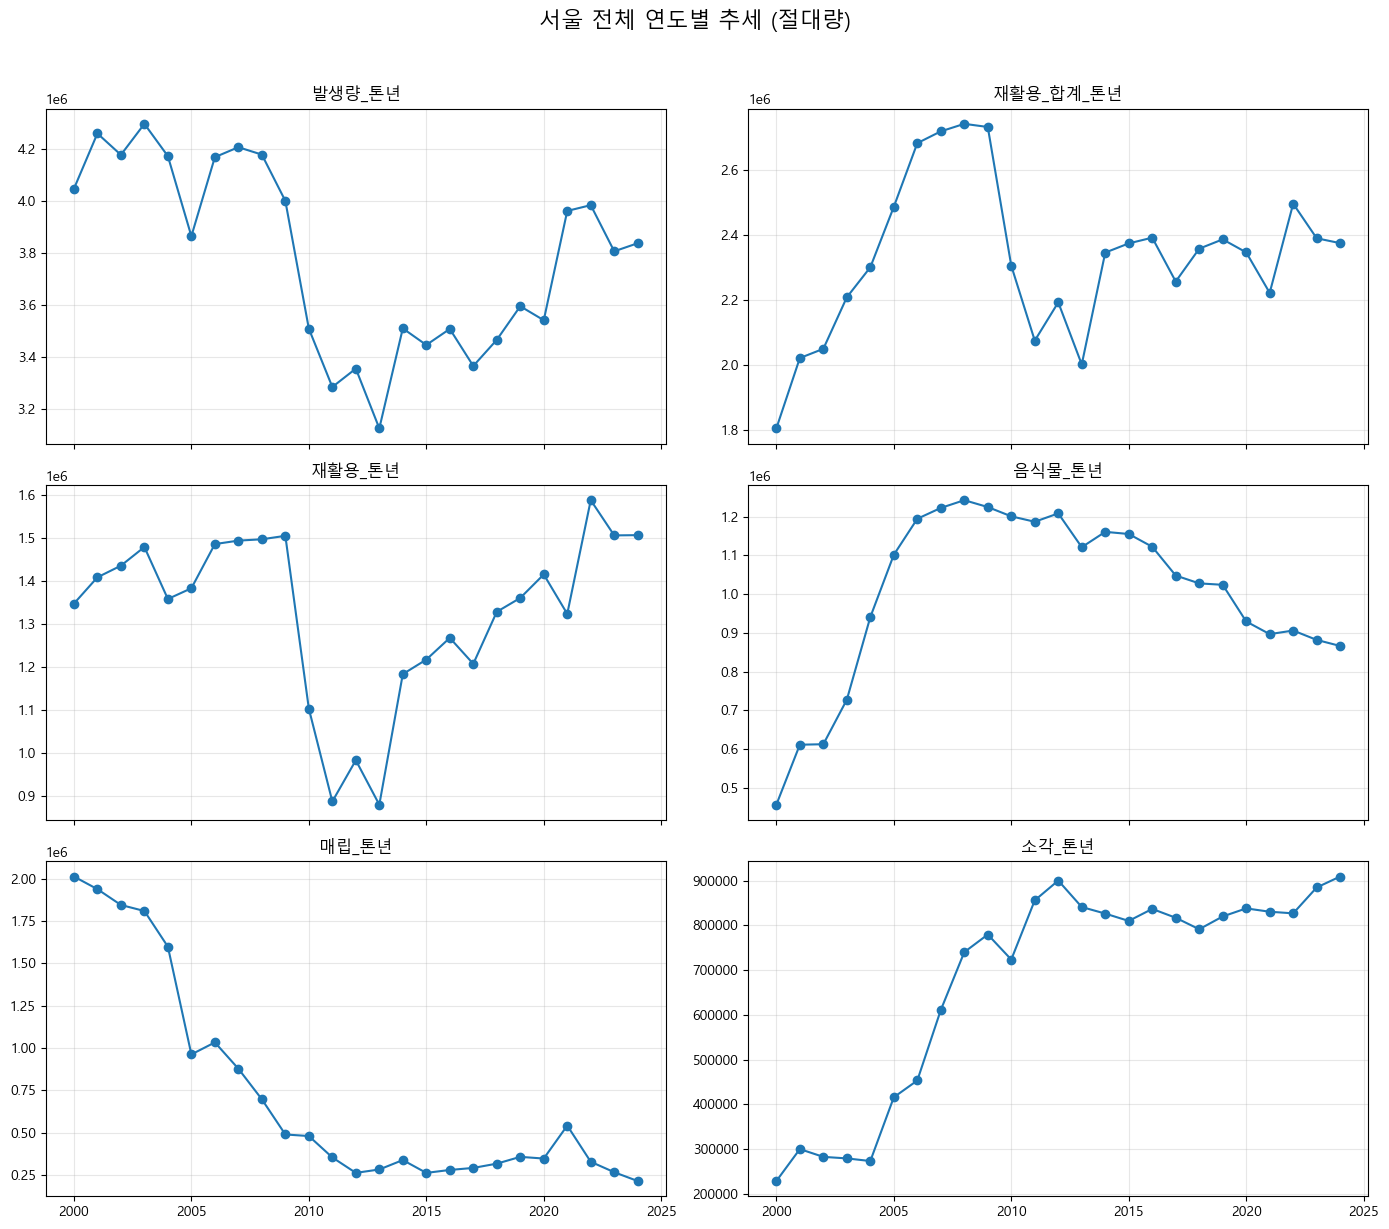

In [30]:
n = len(long_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(long_cols):
    axes[i].plot(yearly_long['연도'], yearly_long[col], marker='o')
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('서울 전체 연도별 추세 (절대량)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

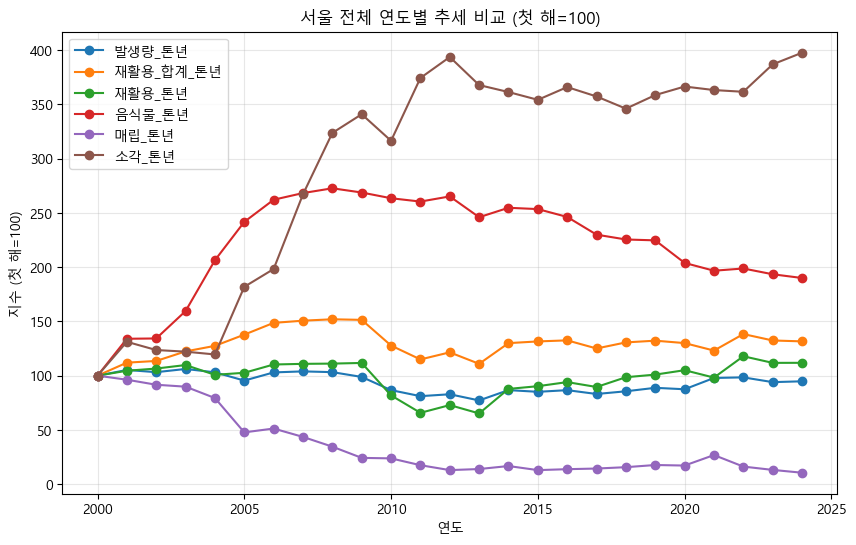

In [31]:
plot_cols = long_cols.copy()

index_df = yearly_long[['연도'] + plot_cols].copy()

for col in plot_cols:
    index_df[col] = index_df[col] / index_df[col].iloc[0] * 100

plt.figure(figsize=(10, 6))
for col in plot_cols:
    plt.plot(index_df['연도'], index_df[col], marker='o', label=col)

plt.title('서울 전체 연도별 추세 비교 (첫 해=100)')
plt.xlabel('연도')
plt.ylabel('지수 (첫 해=100)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

> 소각은 눈에 띄게 증가했고,매립은 감소하는 추세가 보인다.

### 1.2 연도별 소각-매립 비중 변화

- 소각 비중 : 약 40% -> 약 70% 증가  
- 매립 비중: 약 50% -> 약 10% 미만으로 감소

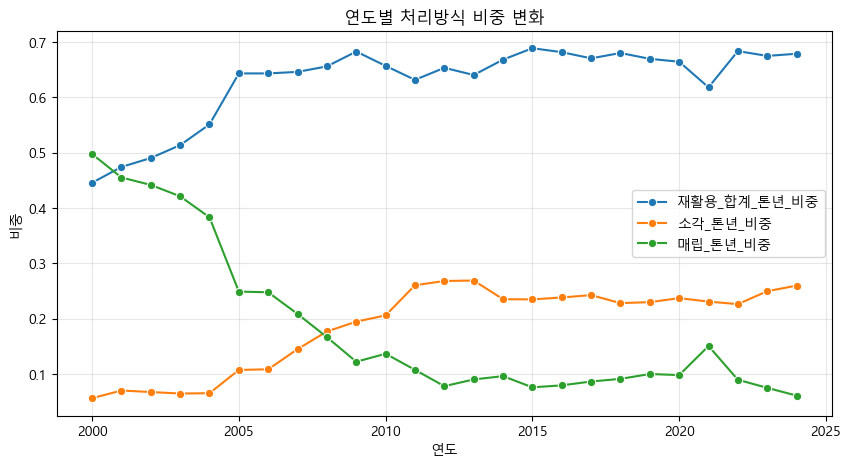

In [32]:
ratio_df = yearly_long.copy()

base_cols = ['재활용_합계_톤년', '소각_톤년', '매립_톤년']
ratio_df['처리합계'] = ratio_df[base_cols].sum(axis=1)

for col in base_cols:
    ratio_df[col + '_비중'] = ratio_df[col] / ratio_df['처리합계']

plt.figure(figsize=(10,5))
for col in [c + '_비중' for c in base_cols]:
    sns.lineplot(data=ratio_df, x='연도', y=col, marker='o', label=col)
plt.title('연도별 처리방식 비중 변화')
plt.ylabel('비중')
plt.grid(alpha=0.3)
plt.show()

매립은 약 200만톤 수준에서 최근에는 20만톤까지 하락세를 보인다.  
소각은 20만톤 수준에서 80만톤 수준까지 증가하며 서울의 쓰레기 처리가 매립에서 소각으로 변화한 것을 확인할 수 있다.

### 1.3 자치구별 평균 쓰레기 발생량

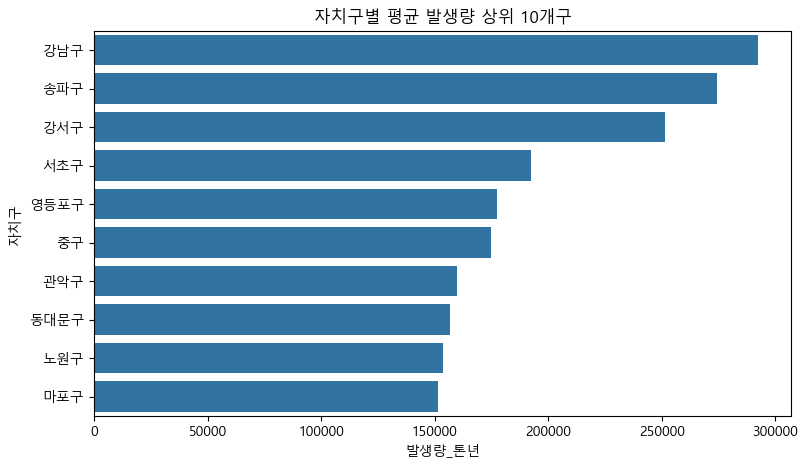

In [33]:
gu_long_mean = df_long.groupby('자치구')[long_cols].mean().round(1)

top_gu = gu_long_mean.sort_values('발생량_톤년', ascending=False).head(10).reset_index()

plt.figure(figsize=(9,5))
sns.barplot(data=top_gu, x='발생량_톤년', y='자치구')
plt.title('자치구별 평균 발생량 상위 10개구')
plt.show()

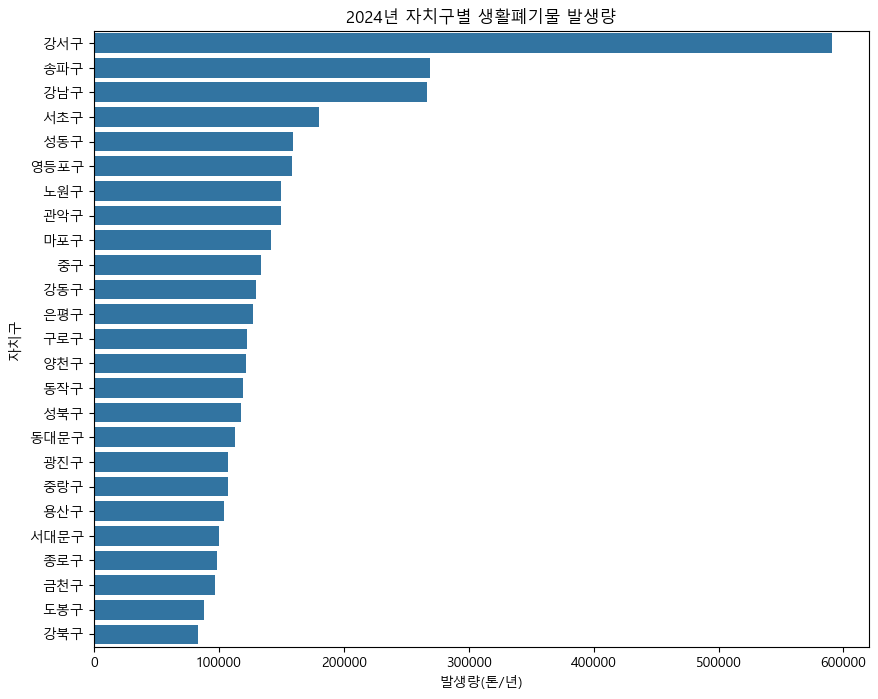

In [34]:
latest_year = df['연도'].max()
df_latest = df[df['연도'] == latest_year].copy()

plot_df = df_latest[['자치구', '발생량_톤년']].sort_values('발생량_톤년', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x='발생량_톤년', y='자치구')
plt.title(f'{latest_year}년 자치구별 생활폐기물 발생량')
plt.xlabel('발생량(톤/년)')
plt.ylabel('자치구')
plt.show()

전 기간 평균 발생량 순위로는 강남구>송파구>강서구>서초구 순이지만,    
2024년 발생량 순위로는 강서구>송파구>강남구>서초구 순이다.   
 강서구가 언제 무엇이 급등했는지 알아보자.

In [35]:
trend_df = df[['자치구', '연도', '발생량_톤년']].dropna().copy()
trend_df = trend_df.sort_values(['자치구', '연도'])

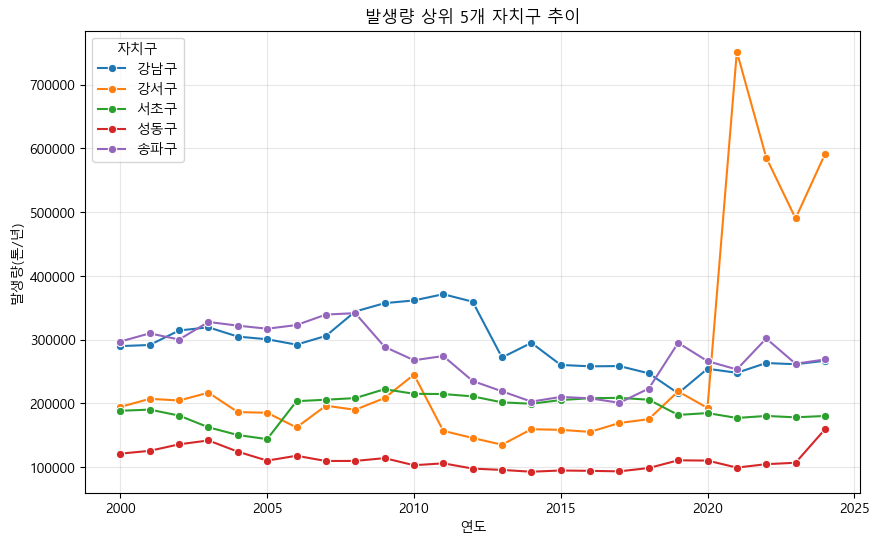

In [36]:
top5_gu = plot_df.head(5)['자치구'].tolist()

top5_trend = trend_df[trend_df['자치구'].isin(top5_gu)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=top5_trend, x='연도', y='발생량_톤년', hue='자치구', marker='o')
plt.title('발생량 상위 5개 자치구 추이')
plt.xlabel('연도')
plt.ylabel('발생량(톤/년)')
plt.grid(alpha=0.3)
plt.show()

## 1.4 자치구별 처리방식 비중 비교

<Figure size 1400x600 with 0 Axes>

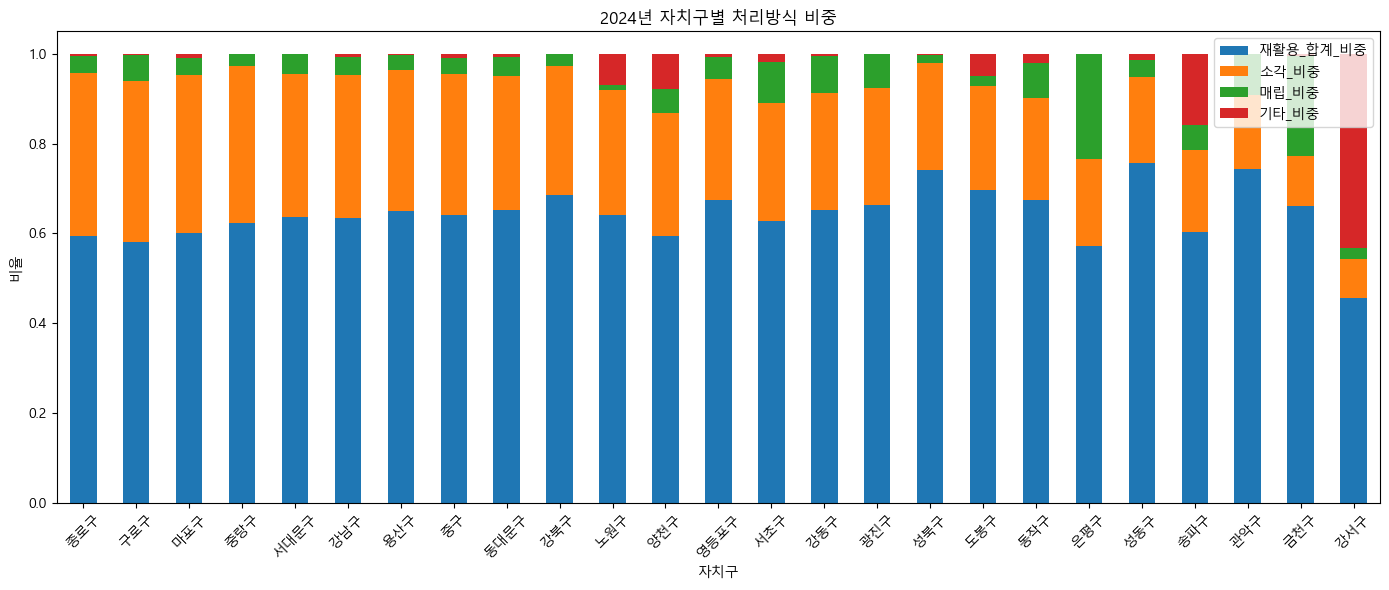

In [40]:
process_cols = ['재활용_합계_톤년', '소각_톤년', '매립_톤년', '기타_톤년']
latest_year = df['연도'].max()

process_df = df[df['연도'] == latest_year][['자치구'] + process_cols].copy()
process_df['기타_톤년'] = process_df['기타_톤년'].fillna(0)

process_df['처리합계'] = process_df[process_cols].sum(axis=1)

for col in process_cols:
    process_df[col.replace('_톤년', '_비중')] = process_df[col] / process_df['처리합계']

ratio_cols = [c for c in process_df.columns if c.endswith('_비중')]

plot_df = (
    process_df[['자치구'] + ratio_cols]
    .set_index('자치구')
    .sort_values('소각_비중', ascending=False)
)

plt.figure(figsize=(14, 6))
plot_df.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title(f'{latest_year}년 자치구별 처리방식 비중')
plt.ylabel('비율')
plt.xlabel('자치구')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== 총발생량 기준 급등 상위 5개 자치구 ===


,자치구,연도,발생량_톤년,총발생_전년대비증감량,총발생_전년대비증감률(%)
0,강서구,2021,751795.0,558998.0,289.941234
1,용산구,2022,216363.0,109190.0,101.882004
2,송파구,2019,294993.0,71686.0,32.101994
3,도봉구,2006,151876.5,67963.0,80.991736
4,마포구,2021,199008.0,64900.0,48.393832



=== 급등한 5개 구에서, 그 급등 연도에 어떤 항목이 얼마나 뛰었는지 ===


C:\Users\yms10\AppData\Local\Temp\ipykernel_25028\263387535.py:53: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  long_df['전년대비증감률(%)'] = long_df.groupby(['자치구', '항목명'])['값'].pct_change() * 100


,자치구,연도,항목명,값,전년대비증감량,전년대비증감률(%)
0,강서구,2021,총발생량,751795.0,558998.0,289.941234
1,강서구,2021,기타,269979.0,269548.0,62540.139211
2,강서구,2021,매립,229973.0,209390.0,1017.295827
3,강서구,2021,재활용합계,212856.0,78995.0,59.012707
4,강서구,2021,소각,38987.0,1066.0,2.811107
5,강서구,2021,음식물,47438.0,-5290.0,-10.032620
6,용산구,2022,재활용합계,178471.0,110137.0,161.174525
7,용산구,2022,총발생량,216363.0,109190.0,101.882004
8,용산구,2022,음식물,24960.0,2295.0,10.125745
9,용산구,2022,소각,31172.0,1683.0,5.707213



=== 각 자치구에서 급등 시점에 가장 크게 같이 뛴 항목 ===


,자치구,연도,항목명,값,전년대비증감량,전년대비증감률(%)
0,강서구,2021,기타,269979.0,269548.0,62540.139211
1,용산구,2022,재활용합계,178471.0,110137.0,161.174525
2,송파구,2019,음식물,151365.5,71905.0,90.491502
3,도봉구,2006,재활용합계,118041.0,66685.5,129.850746
4,마포구,2021,재활용합계,79714.0,-205.0,-0.256510


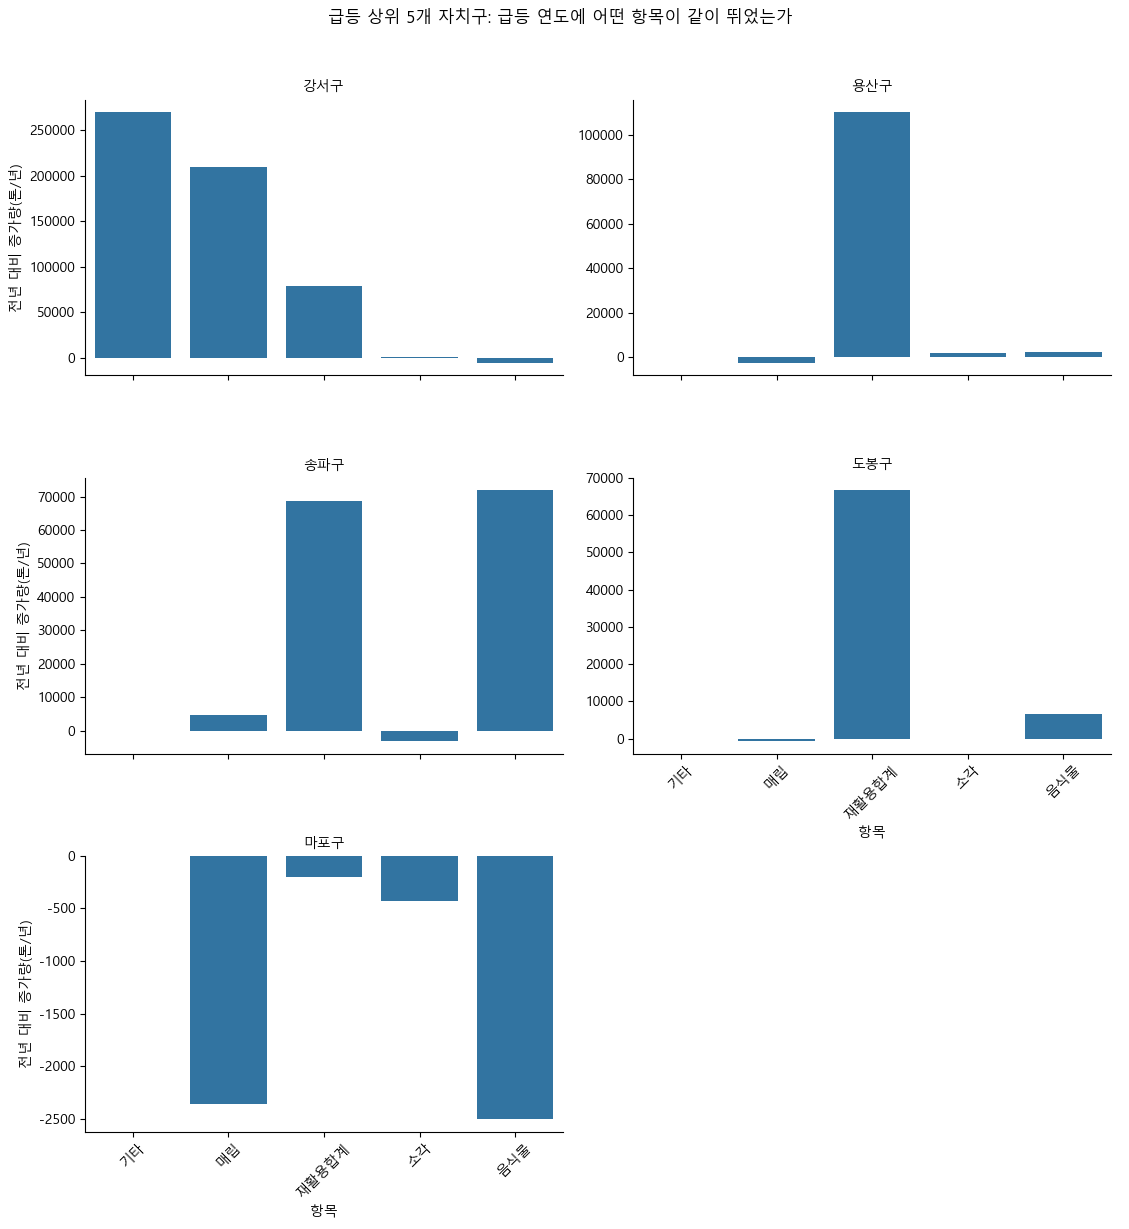

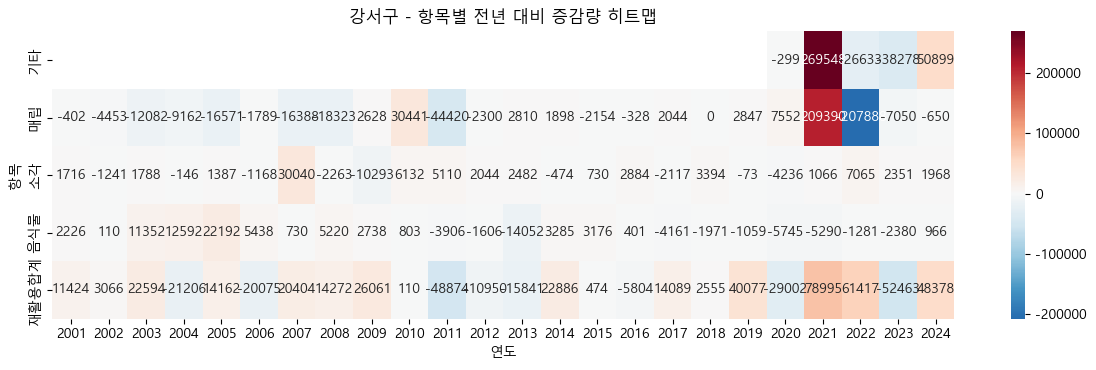

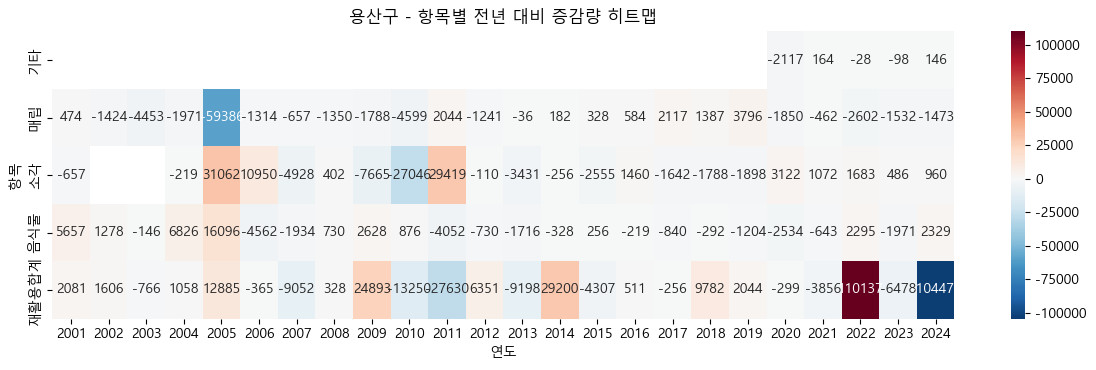

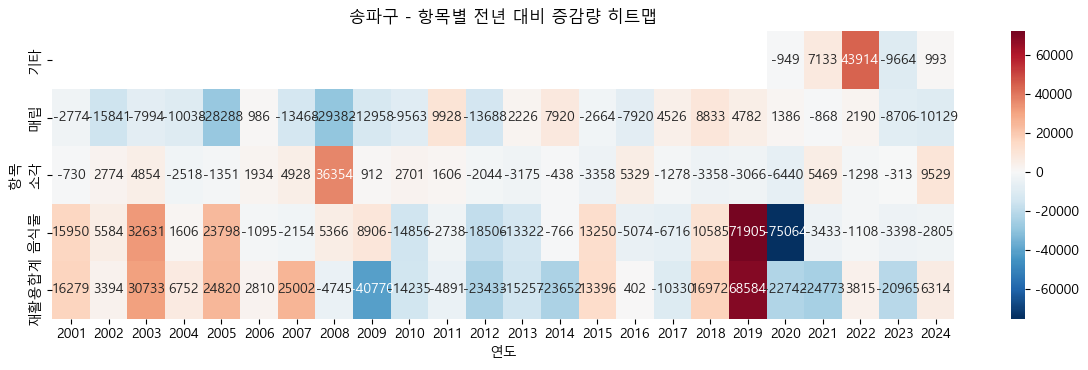

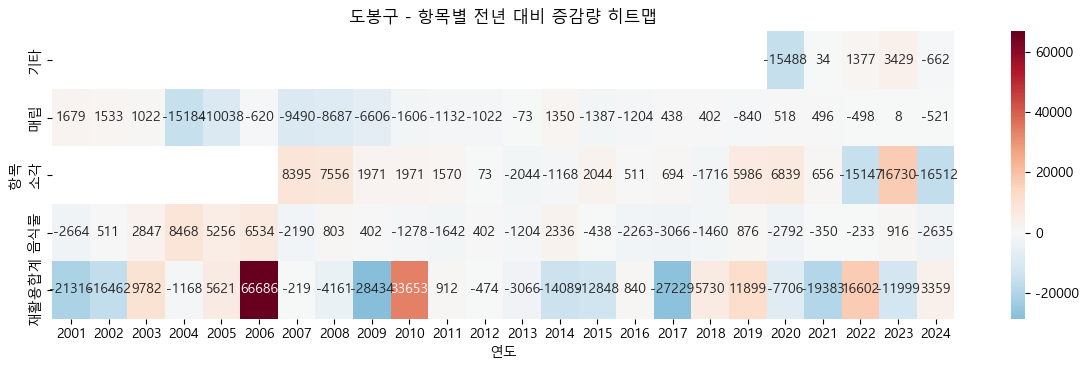

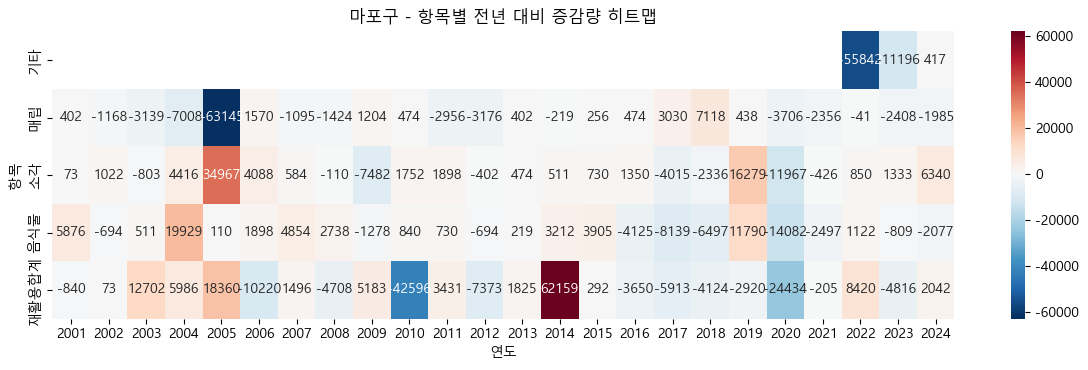

In [41]:



# =========================
# 1. 자치구별 "총발생량 급등 시점" 찾기
# =========================
base = df[['자치구', '연도', '발생량_톤년']].dropna().copy()
base = base.sort_values(['자치구', '연도'])

base['총발생_전년대비증감량'] = base.groupby('자치구')['발생량_톤년'].diff()
base['총발생_전년대비증감률(%)'] = base.groupby('자치구')['발생량_톤년'].pct_change() * 100

# 자치구별로 "가장 크게 급등한 1개 연도"만 추출
idx = base.groupby('자치구')['총발생_전년대비증감량'].idxmax()
gu_peak = base.loc[idx].copy()

# 급등 상위 5개 자치구
top5_gu_peak = gu_peak.sort_values('총발생_전년대비증감량', ascending=False).head(5).reset_index(drop=True)

print("=== 총발생량 기준 급등 상위 5개 자치구 ===")
display(top5_gu_peak)

top5_gu = top5_gu_peak['자치구'].tolist()
peak_year_map = dict(zip(top5_gu_peak['자치구'], top5_gu_peak['연도']))

# =========================
# 2. 급등 원인을 볼 항목들 선택
# =========================

type_cols = {
    '발생량_톤년': '총발생량',
    '재활용_합계_톤년': '재활용합계',
    '음식물_톤년': '음식물',
    '소각_톤년': '소각',
    '매립_톤년': '매립',
    '기타_톤년': '기타'
}

use_cols = ['자치구', '연도'] + list(type_cols.keys())
temp = df[use_cols].copy()
temp = temp[temp['자치구'].isin(top5_gu)].copy()

# long format
long_df = temp.melt(
    id_vars=['자치구', '연도'],
    value_vars=list(type_cols.keys()),
    var_name='항목',
    value_name='값'
)

long_df['항목명'] = long_df['항목'].map(type_cols)
long_df = long_df.sort_values(['자치구', '항목명', '연도'])

# 항목별 전년 대비 증감
long_df['전년대비증감량'] = long_df.groupby(['자치구', '항목명'])['값'].diff()
long_df['전년대비증감률(%)'] = long_df.groupby(['자치구', '항목명'])['값'].pct_change() * 100

# =========================
# 3. "각 자치구의 급등 연도"에 무엇이 같이 뛰었는지 표로 정리
# =========================
result_list = []

for gu in top5_gu:
    peak_year = peak_year_map[gu]
    sub = long_df[(long_df['자치구'] == gu) & (long_df['연도'] == peak_year)].copy()
    sub = sub.sort_values('전년대비증감량', ascending=False)

    result_list.append(sub[['자치구', '연도', '항목명', '값', '전년대비증감량', '전년대비증감률(%)']])

result_df = pd.concat(result_list, ignore_index=True)

print("\n=== 급등한 5개 구에서, 그 급등 연도에 어떤 항목이 얼마나 뛰었는지 ===")
display(result_df)

# =========================
# 4. 자치구별 핵심 급등 항목 1개씩 뽑기
# =========================
non_total = result_df[result_df['항목명'] != '총발생량'].copy()

idx2 = non_total.groupby('자치구')['전년대비증감량'].idxmax()
top_reason_df = non_total.loc[idx2].sort_values('전년대비증감량', ascending=False).reset_index(drop=True)

print("\n=== 각 자치구에서 급등 시점에 가장 크게 같이 뛴 항목 ===")
display(top_reason_df)

# =========================
# 5. 시각화 1: 자치구별 급등 연도 항목 비교
# =========================
plot_df = non_total.copy()

g = sns.catplot(
    data=plot_df,
    x='항목명', y='전년대비증감량',
    col='자치구', col_wrap=2,
    kind='bar', sharey=False,
    height=4, aspect=1.4
)

g.set_titles("{col_name}")
g.set_axis_labels("항목", "전년 대비 증가량(톤/년)")
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("급등 상위 5개 자치구: 급등 연도에 어떤 항목이 같이 뛰었는가", y=1.02)
plt.tight_layout()
plt.show()

# =========================
# 6. 시각화 2: 연도별 히트맵
# =========================
# 각 자치구에서 모든 연도에 대해, 항목별 전년대비증감량을 히트맵으로 보기
for gu in top5_gu:
    sub = long_df[(long_df['자치구'] == gu) & (long_df['항목명'] != '총발생량')].copy()
    heat = sub.pivot_table(index='항목명', columns='연도', values='전년대비증감량')

    plt.figure(figsize=(12, 3.8))
    sns.heatmap(heat, annot=True, fmt='.0f', cmap='RdBu_r', center=0)
    plt.title(f'{gu} - 항목별 전년 대비 증감량 히트맵')
    plt.xlabel('연도')
    plt.ylabel('항목')
    plt.tight_layout()
    plt.show()

- 강서구는 2021년에 ‘기타’ 가 26만톤 이상, ‘매립’이 20만톤 이상 급등했다.  
- 용산구는 2022년에 재활용이 10만톤 이상 급등했다.  
- 송파구는 2019년에 음식물이 6만톤 이상, 재활용이 7만톤 이상 급등했다.  

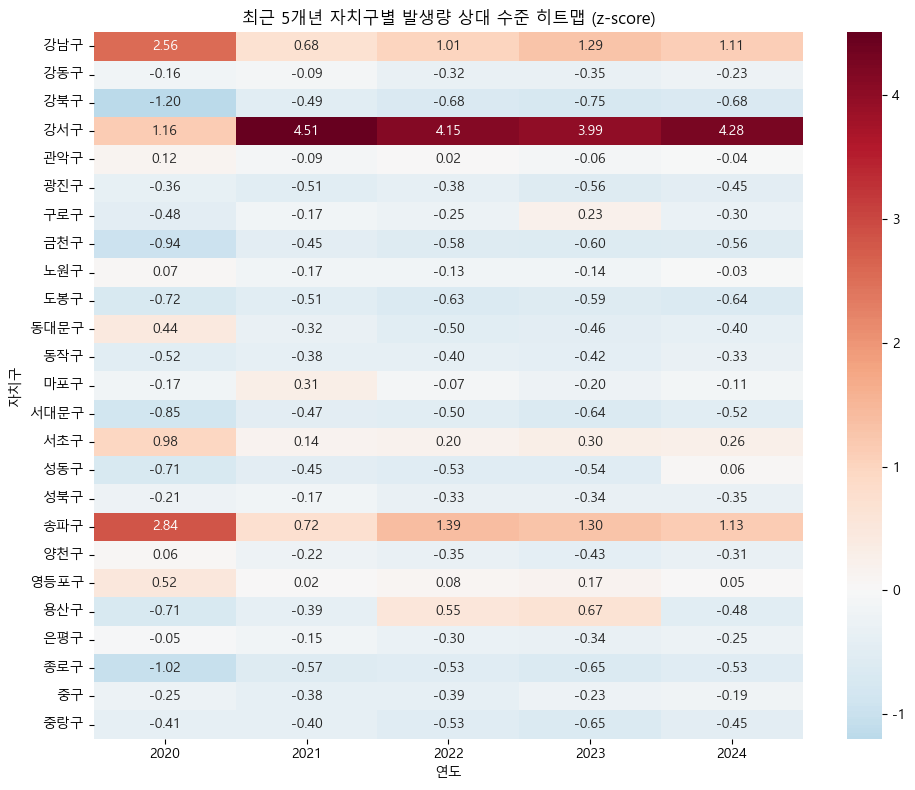

In [47]:
recent_years = sorted(df['연도'].unique())[-5:]

heat_df = df[df['연도'].isin(recent_years)][['자치구', '연도', '발생량_톤년']].dropna().copy()

pivot_df = heat_df.pivot(index='자치구', columns='연도', values='발생량_톤년')

# 연도별 상대 비교를 보기 위해 z-score 표준화
zscore_pivot = pivot_df.apply(lambda col: (col - col.mean()) / col.std(), axis=0)

plt.figure(figsize=(10, 8))
sns.heatmap(zscore_pivot, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('최근 5개년 자치구별 발생량 상대 수준 히트맵 (z-score)')
plt.xlabel('연도')
plt.ylabel('자치구')
plt.tight_layout()
plt.show()

# 1.5 처리방식 특화도(LQ) + 구조변화지수  
### 1.5.1. 서울 평균 대비 자치구 처리방식 특화도

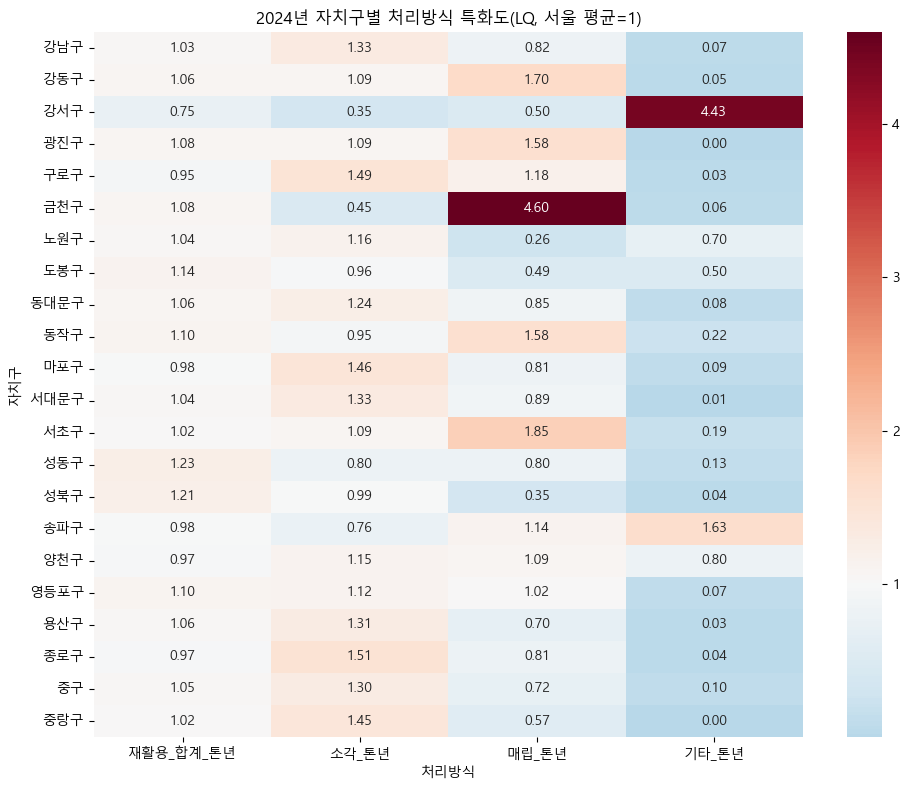


[재활용_합계_톤년] 특화 상위 5개 자치구


,자치구,재활용_합계_톤년
0,성동구,1.234221
1,성북구,1.207400
2,도봉구,1.136743
3,영등포구,1.100406
4,동작구,1.100087



[소각_톤년] 특화 상위 5개 자치구


,자치구,소각_톤년
0,종로구,1.510790
1,구로구,1.494042
2,마포구,1.460859
3,중랑구,1.452052
4,서대문구,1.331531



[매립_톤년] 특화 상위 5개 자치구


,자치구,매립_톤년
0,금천구,4.599156
1,서초구,1.854331
2,강동구,1.696903
3,동작구,1.584119
4,광진구,1.575006



[기타_톤년] 특화 상위 5개 자치구


,자치구,기타_톤년
0,강서구,4.426931
1,송파구,1.627248
2,양천구,0.799236
3,노원구,0.703733
4,도봉구,0.496052


In [42]:
# 처리방식이 모두 있는 가장 최근 연도 사용
process_cols = ['재활용_합계_톤년', '소각_톤년', '매립_톤년', '기타_톤년']

process_year = (
    df.dropna(subset=process_cols)
      .groupby('연도')
      .size()
      .reset_index(name='n')
      .sort_values('연도')
      .iloc[-1]['연도']
)

process_df = df[df['연도'] == process_year][['자치구'] + process_cols].dropna().copy()
process_df = process_df.set_index('자치구')

# 자치구 내부 비중
gu_share = process_df.div(process_df.sum(axis=1), axis=0)

# 서울 전체 비중
seoul_share = process_df.sum(axis=0) / process_df.sum(axis=0).sum()

# LQ = 자치구 비중 / 서울 전체 비중
lq_df = gu_share.div(seoul_share, axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(lq_df, annot=True, cmap='RdBu_r', center=1, fmt='.2f')
plt.title(f'{process_year}년 자치구별 처리방식 특화도(LQ, 서울 평균=1)')
plt.xlabel('처리방식')
plt.ylabel('자치구')
plt.tight_layout()
plt.show()

# 각 처리방식별 특화 상위 자치구
for col in lq_df.columns:
    print(f'\n[{col}] 특화 상위 5개 자치구')
    display(
        lq_df[[col]].sort_values(col, ascending=False).head(5).reset_index()
    )

### 1. [재활용] 성동구, 성북구 (LQ 1.23 ~ 1.20)- 모범구

- **특징**: 서울 평균보다 약 **20~23% 더 많이 재활용**에 집중되어있음.
- **해석**: 이 지역들은 주거 밀집도가 높거나, 구 차원에서 재활용 분리배출 시스템(예: 성동구의 '성동 푸르미 재활용 정거장' 등)을 매우 체계적으로 운영하고 있을 가능성 있음.

### 2. [소각] 종로구, 구로구, 마포구 (LQ 1.51 ~ 1.46)

- **특징**: 서울 평균보다 **50% 정도 소각 비중이 높음.**
- **해석**: 종로구는 상업 지구가 많아 재활용이 어려운 가연성 폐기물 배출이 많을 수 있고, 마포구는 구 내부에 대규모 **자원회수시설(소각장)**이 위치해 있어 관내 소각 처리 비중이 자연스럽게 높게 나타나는 경향이 보임.

### 3. [매립] 금천구 (LQ 4.59 - 심각)

- **특징**: 서울 평균보다 **4.6배나 더 많이 땅에 묻고 있다.**
- **해석**: 금천구 내에 소각 시설이나 재활용 선별장이 부족하여 인근 매립지로 바로 보내는 양이 많거나
- 혹은 금천구의 산업 단지(가산디지털단지 등)에서 나오는 폐기물 중 소각이 불가능한 '불연성 폐기물'의 비중이 비정상적으로 높을 가능성이 있음.
- **정책 제언**: 금천구는 현재 서울에서 가장 **매립 의존도가 높은 지역**이므로, 소각이나 재활용으로 전환하려는 노력이 가장 시급한 곳으로 보임.

### 4. [기타] 강서구 (LQ 4.42 - 원인 불명)

- **특징**: 서울 평균보다 **4.4배나 '기타' 방식**으로 처리함.
- **해석**: 여기서 '기타'는 보통 사설 업체 처리나 대형 폐기물, 혹은 특수 공정(건설 폐기물 등)을 의미함.
- 강서구는 마곡지구 개발 등 대규모 건설 현장이 많았거나, 김포공항 주변의 특수한 폐기물 처리 체계가 반영되었을 확률
- 혹은 강서구 내에 대규모 음식물 쓰레기 자원화 시설이 있어 '기타'로 분류되었을 수도


,자치구,재활용_합계_톤년,소각_톤년,매립_톤년,기타_톤년
99,강서구,270188.0,50371.00,14385.00,255967.000000
199,금천구,64032.0,10564.00,21528.00,570.000000
0,서울시 평균,94950.6,36356.72,8566.64,15460.545455


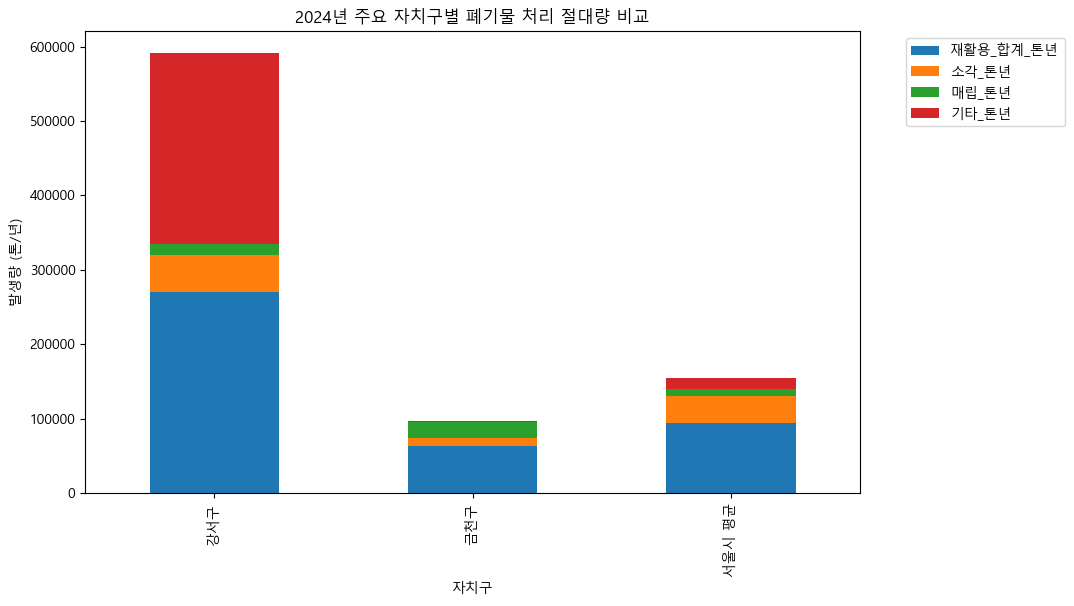

In [43]:
# 분석 대상 구 선정
target_gus = ['금천구', '강서구']
cols_to_check = ['자치구', '재활용_합계_톤년', '소각_톤년', '매립_톤년', '기타_톤년']

# 1. 대상 구와 서울 전체 평균 비교용 데이터 생성
target_df = df[df['연도'] == process_year][cols_to_check].copy()
seoul_avg = target_df.mean(numeric_only=True).to_frame().T
seoul_avg['자치구'] = '서울시 평균'

compare_df = pd.concat([target_df[target_df['자치구'].isin(target_gus)], seoul_avg])
display(compare_df)

# 2. 시각화: 절대량 비교 (막대 그래프)
compare_df.set_index('자치구').plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title(f'{process_year}년 주요 자치구별 폐기물 처리 절대량 비교')
plt.ylabel('발생량 (톤/년)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 2.트랙B :인구 대비 EDA

In [45]:
pop_cols = [
    '발생량_톤년',
    '주민수',
    '주민1인당_생활폐기물_kg_일',
    '생활계폐기물_톤_일'
]
pop_cols = [c for c in pop_cols if c in df.columns]

df_pop = df[['자치구', '연도'] + pop_cols].dropna()
print(df_pop['연도'].min(), df_pop['연도'].max(), df_pop.shape)

2009 2024 (400, 6)


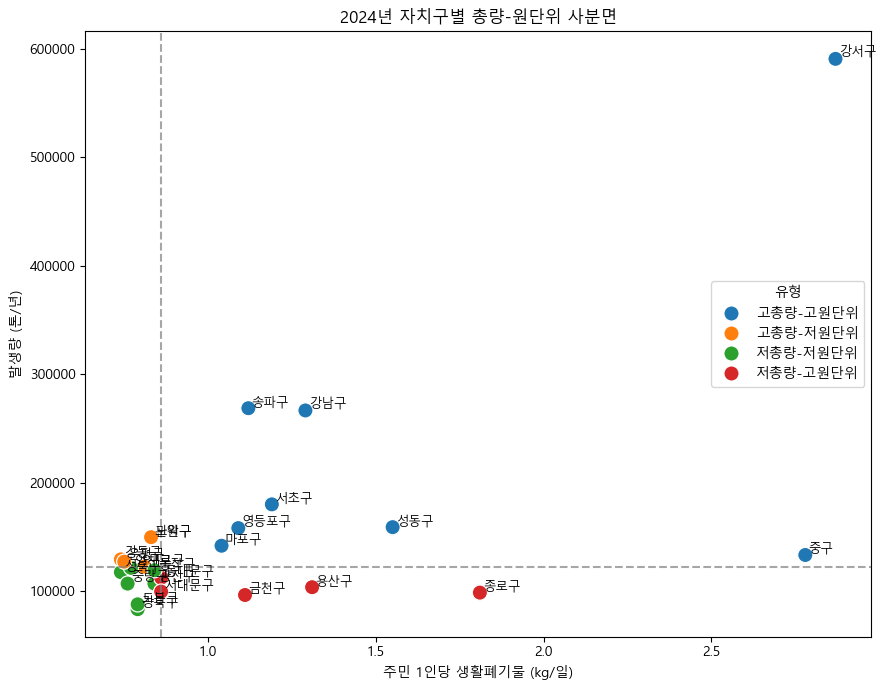

,자치구,발생량_톤년,주민1인당_생활폐기물_kg_일,유형
99,강서구,590910.0,2.87,고총량-고원단위
449,송파구,268890.0,1.12,고총량-고원단위
24,강남구,266815.0,1.29,고총량-고원단위
374,서초구,180257.0,1.19,고총량-고원단위
399,성동구,159245.0,1.55,고총량-고원단위
499,영등포구,158377.0,1.09,고총량-고원단위
324,마포구,142121.0,1.04,고총량-고원단위
599,중구,133576.0,2.78,고총량-고원단위
224,노원구,150001.0,0.83,고총량-저원단위
124,관악구,149864.0,0.83,고총량-저원단위


In [46]:
latest_year = df['연도'].max()

quad_df = df[df['연도'] == latest_year][
    ['자치구', '발생량_톤년', '주민1인당_생활폐기물_kg_일']
].dropna().copy()

x_med = quad_df['주민1인당_생활폐기물_kg_일'].median()
y_med = quad_df['발생량_톤년'].median()

quad_df['유형'] = np.select(
    [
        (quad_df['주민1인당_생활폐기물_kg_일'] >= x_med) & (quad_df['발생량_톤년'] >= y_med),
        (quad_df['주민1인당_생활폐기물_kg_일'] < x_med) & (quad_df['발생량_톤년'] >= y_med),
        (quad_df['주민1인당_생활폐기물_kg_일'] < x_med) & (quad_df['발생량_톤년'] < y_med),
    ],
    ['고총량-고원단위', '고총량-저원단위', '저총량-저원단위'],
    default='저총량-고원단위'
)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=quad_df,
    x='주민1인당_생활폐기물_kg_일',
    y='발생량_톤년',
    hue='유형',
    s=120
)

plt.axvline(x_med, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y_med, color='gray', linestyle='--', alpha=0.7)

for _, row in quad_df.iterrows():
    plt.text(
        row['주민1인당_생활폐기물_kg_일'] + 0.01,
        row['발생량_톤년'] + 2000,
        row['자치구'],
        fontsize=9
    )

plt.title(f'{latest_year}년 자치구별 총량-원단위 사분면')
plt.xlabel('주민 1인당 생활폐기물 (kg/일)')
plt.ylabel('발생량 (톤/년)')
plt.tight_layout()
plt.show()

display(quad_df.sort_values(['유형', '발생량_톤년'], ascending=[True, False]))

## 트랙 C: 최근 재활용률 EDA

In [50]:
recent_cols = [
    '재활용률',
    '발생량_톤년',
    '재활용_합계_톤년',
    '소각_톤년',
    '매립_톤년'
]
recent_cols = [c for c in recent_cols if c in df.columns]

df_recent = df[['자치구', '연도'] + recent_cols].dropna()
print(df_recent['연도'].min(), df_recent['연도'].max(), df_recent.shape)

2020 2024 (125, 7)


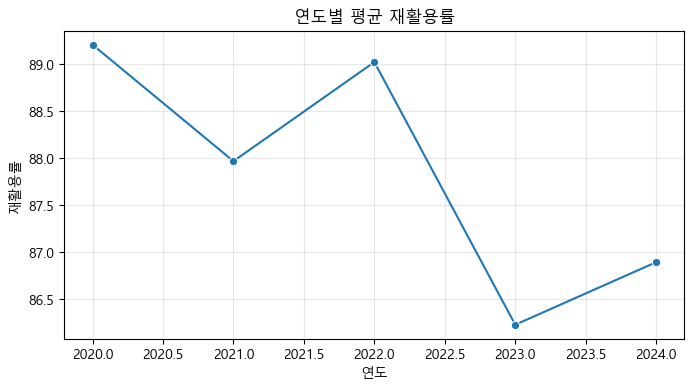

In [51]:
recent_yearly = df_recent.groupby('연도')[['재활용률']].mean().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(data=recent_yearly, x='연도', y='재활용률', marker='o')
plt.title('연도별 평균 재활용률')
plt.grid(alpha=0.3)
plt.show()

,자치구,재활용률
299,동작구,96.0
249,도봉구,95.2
374,서초구,94.4
399,성동구,92.7
424,성북구,91.5
524,용산구,91.3
499,영등포구,91.2
549,은평구,91.0
49,강동구,90.2
599,중구,89.6


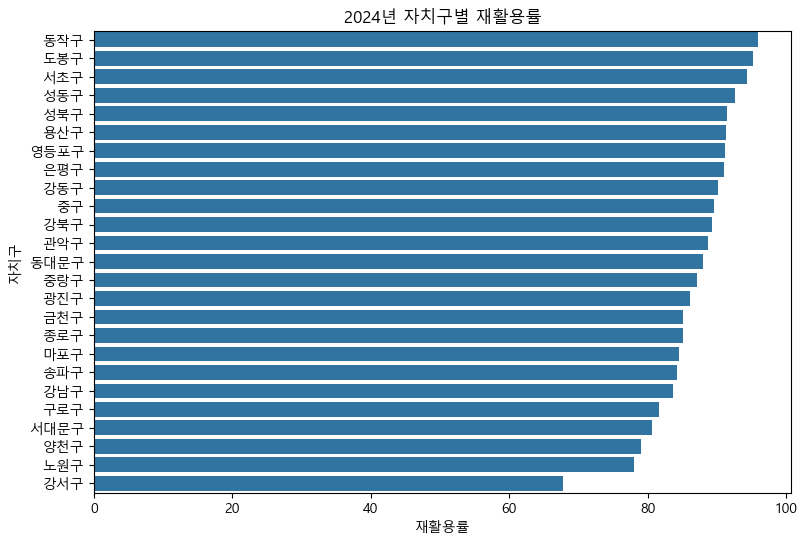

In [52]:
latest_recent_year = df_recent['연도'].max()
recent_latest = df_recent[df_recent['연도'] == latest_recent_year].copy()

top_recycle = recent_latest[['자치구', '재활용률']].sort_values('재활용률', ascending=False)
display(top_recycle)

plt.figure(figsize=(9,6))
sns.barplot(data=top_recycle, x='재활용률', y='자치구')
plt.title(f'{latest_recent_year}년 자치구별 재활용률')
plt.show()